# Inside a Large Language Model — Build One With NumPy

### What we are actually building

A language model does exactly one thing:

$$P(\text{next token} \mid \text{all previous tokens})$$

Everything else it appears to do — grammar, facts, style — is a side effect of being very good at that.

### The ten steps

| # | Step | Matrix involved | Shape |
|---|------|-----------------|-------|
| 1 | Tokenize | *(none — just a lookup table)* | text → `n` integers |
| 2 | Embed | `E` | `V × d` |
| 3 | Add position | `P` | `n × d` |
| 4 | Project | `W_Q`, `W_K`, `W_V` | `d × d_k` |
| 5 | Score | `S = Q Kᵀ / √d_k` | `n × n` |
| 6 | Mask + softmax | `A` | `n × n` |
| 7 | Mix values | `Z = A V`, then `W_O` | `n × d_k`, `d × d` |
| 8 | Add & Norm | `γ`, `β` | `d` |
| 9 | Feed-forward | `W₁`, `W₂` | `d × d_ff`, `d_ff × d` |
| 10 | LM head | `W_U` | `d × V` |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Print floats with 3 decimals instead of scientific notation — much easier to read.
np.set_printoptions(precision=3, suppress=True, linewidth=120)

def show(name, M, note=""):
    """Pretty-print a matrix together with its shape."""
    M = np.asarray(M)
    print(f"{name}   shape = {M.shape}   {note}")
    print(M)
    print()

print("NumPy version:", np.__version__)

NumPy version: 2.4.4


---
## 1. Tokenization — text becomes integers

A model cannot read letters. The very first thing that happens is that text is chopped into
**tokens** and each token is replaced by its integer ID.

Real models use ~50,000 tokens produced by an algorithm called Byte-Pair Encoding, and a token is
often a *piece* of a word (`unbelievable` → `un` + `believ` + `able`). We will use a toy
vocabulary of six tokens so that everything stays readable.

In [ ]:
vocab = ["<pad>", "the", "cat", "sat", "on", "mat"]

token_to_id = {t: i for i, t in enumerate(vocab)}
id_to_token = {i: t for i, t in enumerate(vocab)}

V = len(vocab)   # vocabulary size
print("V (vocabulary size) =", V)
print("token → id :", token_to_id)


def encode(text):
    """text -> list of integer ids (whitespace split, because our toy vocab is word-level)"""
    return [token_to_id[w] for w in text.lower().split()]

def decode(ids):
    """list of integer ids -> text"""
    return " ".join(id_to_token[i] for i in ids)


prompt = "the cat sat"
ids = encode(prompt)
n = len(ids)          # sequence length

print()
print("prompt :", repr(prompt))
print("ids    :", ids)
print("n (sequence length) =", n)
print("decode back:", repr(decode(ids)))

V (vocabulary size) = 6
token → id : {'<pad>': 0, 'the': 1, 'cat': 2, 'sat': 3, 'on': 4, 'mat': 5}

prompt : 'the cat sat'
ids    : [1, 2, 3]
n (sequence length) = 3
decode back: 'the cat sat'


---
## 2. The embedding matrix `E`  —  shape `V × d`

`E` is a lookup table: **one row per vocabulary token**, each row a vector of `d` numbers.

Formally, embedding is a matrix multiplication:

$$X_{tok} = \text{OneHot}(\text{ids}) \cdot E \qquad (n \times V)\cdot(V \times d) = (n \times d)$$

But multiplying a one-hot row by a matrix just *selects a row* — so in real code it is written as an
array index. We will verify below that the two give identical results.

`E` is **learned**. It starts as random noise; training moves related tokens close together.
We hard-code sensible values here so the output is reproducible.

In [3]:
d = 4    # model width (d_model). Real models use 768, 4096, 12288 ...

# One row per token. Hand-picked so the numbers stay readable.
E = np.array([
    [0.0, 0.0, 0.0, 0.0],   # <pad>
    [0.2, 0.9, 0.1, 0.3],   # the
    [0.8, 0.1, 0.7, 0.2],   # cat
    [0.3, 0.4, 0.9, 0.6],   # sat
    [0.5, 0.7, 0.2, 0.8],   # on
    [0.9, 0.2, 0.4, 0.1],   # mat
])

show("E", E, "(one row per vocabulary token)")

# --- The slow, explicit way: build a one-hot matrix and multiply ---
one_hot = np.zeros((n, V))
one_hot[np.arange(n), ids] = 1
show("OneHot(ids)", one_hot, "(n x V — a single 1 in each row)")

X_tok_matmul = one_hot @ E

# --- The fast way everyone actually uses: fancy indexing ---
X_tok = E[ids]

show("X_tok = E[ids]", X_tok, "(n x d)")
print("Do the two methods agree?", np.allclose(X_tok, X_tok_matmul))
print("\nRow 1 is the vector for 'cat':", E[token_to_id['cat']])

E   shape = (6, 4)   (one row per vocabulary token)
[[0.  0.  0.  0. ]
 [0.2 0.9 0.1 0.3]
 [0.8 0.1 0.7 0.2]
 [0.3 0.4 0.9 0.6]
 [0.5 0.7 0.2 0.8]
 [0.9 0.2 0.4 0.1]]

OneHot(ids)   shape = (3, 6)   (n x V — a single 1 in each row)
[[0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]]

X_tok = E[ids]   shape = (3, 4)   (n x d)
[[0.2 0.9 0.1 0.3]
 [0.8 0.1 0.7 0.2]
 [0.3 0.4 0.9 0.6]]

Do the two methods agree? True

Row 1 is the vector for 'cat': [0.8 0.1 0.7 0.2]


---
## 3. Positional encoding `P`  —  shape `n × d`

Attention (which we build in a moment) treats its input as an unordered *set*. Without extra help,
`"the cat sat"` and `"sat cat the"` would produce identical output.

The fix is to add a vector that depends only on the **position**:

$$P(\text{pos}, 2i) = \sin\!\left(\frac{\text{pos}}{10000^{2i/d}}\right)
\qquad
P(\text{pos}, 2i+1) = \cos\!\left(\frac{\text{pos}}{10000^{2i/d}}\right)$$

Even columns get a sine, odd columns a cosine, and each pair of columns oscillates at a different
frequency. Think of a clock with many hands moving at different speeds: read all the hands together
and you know the exact time.

Then simply **add** it to the token embeddings — the shape does not change:

$$X = X_{tok} + P \qquad (n\times d) + (n \times d) = (n \times d)$$

In [4]:
def positional_encoding(n, d):
    """Fixed sinusoidal positional encodings, shape (n, d)."""
    P = np.zeros((n, d))
    pos = np.arange(n)[:, None]          # column vector of positions
    i   = np.arange(0, d, 2)[None, :]    # even column indices
    angle = pos / np.power(10000, i / d)
    P[:, 0::2] = np.sin(angle)
    P[:, 1::2] = np.cos(angle)
    return P


P = positional_encoding(n, d)
show("P", P, "(n x d — depends only on position, never on the words)")

X = X_tok + P
show("X = X_tok + P", X, "(n x d — the hidden state)")

P   shape = (3, 4)   (n x d — depends only on position, never on the words)
[[ 0.     1.     0.     1.   ]
 [ 0.841  0.54   0.01   1.   ]
 [ 0.909 -0.416  0.02   1.   ]]

X = X_tok + P   shape = (3, 4)   (n x d — the hidden state)
[[ 0.2    1.9    0.1    1.3  ]
 [ 1.641  0.64   0.71   1.2  ]
 [ 1.209 -0.016  0.92   1.6  ]]



Let's look at more positions and more dimensions so the wave structure is visible.
Notice the left-hand columns oscillate fast and the right-hand columns oscillate slowly —
that is what makes every row a unique fingerprint.

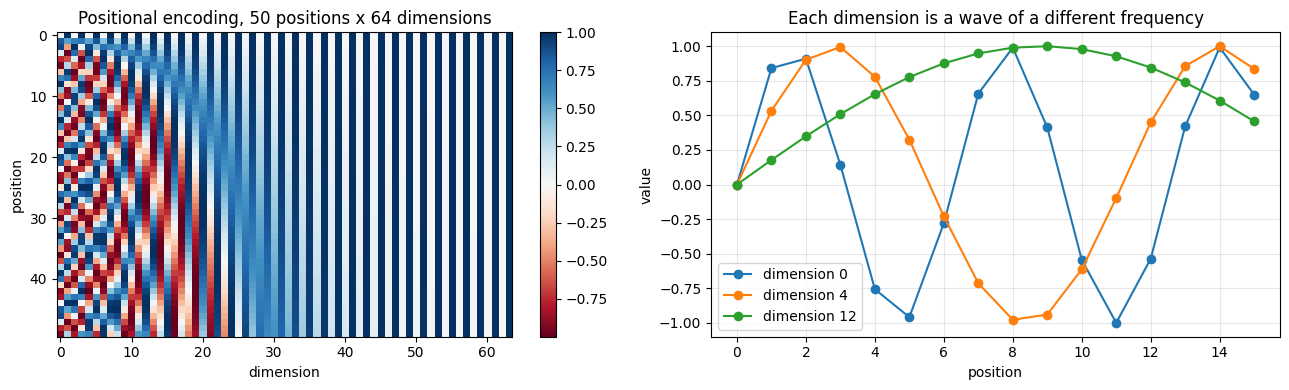

In [5]:
P_big = positional_encoding(50, 64)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

im = axes[0].imshow(P_big, aspect="auto", cmap="RdBu")
axes[0].set_title("Positional encoding, 50 positions x 64 dimensions")
axes[0].set_xlabel("dimension"); axes[0].set_ylabel("position")
fig.colorbar(im, ax=axes[0])

for dim in (0, 4, 12):
    axes[1].plot(P_big[:16, dim], marker="o", label=f"dimension {dim}")
axes[1].set_title("Each dimension is a wave of a different frequency")
axes[1].set_xlabel("position"); axes[1].set_ylabel("value")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## 4. Q, K, V — three different views of the same `X`

Now the attention mechanism begins. We create three new matrices from `X` by multiplying it with
three **learned** projection matrices:

$$Q = X W_Q \qquad K = X W_K \qquad V = X W_V$$
$$(n \times d)\cdot(d \times d_k) = (n \times d_k)$$

Think of a library search:

| | name | the question it answers |
|---|---|---|
| `Q` | **Query** | *"what am I looking for?"* |
| `K` | **Key** | *"what do I contain?"* |
| `V` | **Value** | *"what will I hand over?"* |

`W_Q`, `W_K` and `W_V` all have the same shape — only their learned contents differ.
For this toy we use one head, so `d_k = d = 4`.

In [6]:
d_k = d   # single head for now, so the head width equals the model width

# Learned projection matrices (hand-picked here; in reality gradient descent finds them).
W_Q = np.eye(4) * 0.5 + 0.1
W_K = np.array([[0, 1, 0, 0],
                [1, 0, 0, 0],
                [0, 0, 0, 1],
                [0, 0, 1, 0]], dtype=float) * 0.5 + 0.1
W_V = np.eye(4) * 0.8 + 0.05

Q = X @ W_Q
K = X @ W_K
Vmat = X @ W_V      # named Vmat so it does not clash with V = vocabulary size

show("W_Q", W_Q, "(d x d_k)")
show("Q = X @ W_Q", Q, "(n x d_k)")
show("K = X @ W_K", K, "(n x d_k)")
show("V = X @ W_V", Vmat, "(n x d_k)")

W_Q   shape = (4, 4)   (d x d_k)
[[0.6 0.1 0.1 0.1]
 [0.1 0.6 0.1 0.1]
 [0.1 0.1 0.6 0.1]
 [0.1 0.1 0.1 0.6]]

Q = X @ W_Q   shape = (3, 4)   (n x d_k)
[[0.45  1.3   0.4   1.   ]
 [1.24  0.739 0.774 1.019]
 [0.976 0.363 0.831 1.171]]

K = X @ W_K   shape = (3, 4)   (n x d_k)
[[1.3   0.45  1.    0.4  ]
 [0.739 1.24  1.019 0.774]
 [0.363 0.976 1.171 0.831]]

V = X @ W_V   shape = (3, 4)   (n x d_k)
[[0.335 1.695 0.255 1.215]
 [1.523 0.722 0.778 1.17 ]
 [1.153 0.173 0.922 1.465]]



---
## 5. Attention scores  `S = Q Kᵀ / √d_k`  —  shape `n × n`

Every token's **query** is compared against every token's **key** with a dot product:

$$S = \frac{Q K^{\top}}{\sqrt{d_k}}$$

`S[i][j]` answers: *how relevant is token `j` to token `i`?*

### Why divide by √d_k ?

A dot product of `d_k` terms grows roughly like `√d_k`. If the scores get large, `softmax` saturates
into a near one-hot vector, its gradient collapses towards zero, and the model stops learning.
Dividing keeps the variance near 1 no matter how wide the head is. The next cell demonstrates it.

In [7]:
S = Q @ K.T / np.sqrt(d_k)
show("S = Q @ K.T / sqrt(d_k)", S, "(n x n — one score per token PAIR)")

# --- Why the scaling matters: variance of a dot product grows with d_k ---
rng = np.random.default_rng(0)
print("standard deviation of raw dot products, for random vectors:")
for dk in (4, 64, 512, 4096):
    a = rng.normal(size=(2000, dk))
    b = rng.normal(size=(2000, dk))
    raw    = np.sum(a * b, axis=1)
    scaled = raw / np.sqrt(dk)
    print(f"  d_k = {dk:5d}:  unscaled std = {raw.std():8.2f}   scaled std = {scaled.std():5.2f}")

S = Q @ K.T / sqrt(d_k)   shape = (3, 3)   (n x n — one score per token PAIR)
[[0.985 1.563 1.366]
 [1.563 1.706 1.463]
 [1.366 1.463 1.328]]

standard deviation of raw dot products, for random vectors:
  d_k =     4:  unscaled std =     2.04   scaled std =  1.02
  d_k =    64:  unscaled std =     7.85   scaled std =  0.98
  d_k =   512:  unscaled std =    22.56   scaled std =  1.00


  d_k =  4096:  unscaled std =    64.20   scaled std =  1.00


---
## 6. The causal mask — a token may not read the future

We train the model to predict the *next* token. If position 2 were allowed to look at position 3,
predicting position 3 would be trivial — the answer would already be in the input.

So before the softmax we set every score above the diagonal to `-∞`:

$$S_{ij} \leftarrow -\infty \quad \text{if } j > i$$

Because $e^{-\infty} = 0$, those positions receive **exactly zero** attention weight after softmax.
This single line is what makes a model "decoder-only" / GPT-style.

In [8]:
mask = np.triu(np.ones((n, n)), k=1).astype(bool)   # True above the diagonal
show("mask", mask.astype(int), "(1 = blocked, must not be seen)")

S_masked = S.copy()
S_masked[mask] = -np.inf
show("S masked", S_masked, "(n x n)")

mask   shape = (3, 3)   (1 = blocked, must not be seen)
[[0 1 1]
 [0 0 1]
 [0 0 0]]

S masked   shape = (3, 3)   (n x n)
[[0.985  -inf  -inf]
 [1.563 1.706  -inf]
 [1.366 1.463 1.328]]



---
## 7. Softmax → the attention weights `A`

$$A_{ij} = \frac{\exp(S_{ij})}{\sum_k \exp(S_{ik})}$$

Softmax is applied **along each row independently**. After it:

* every entry is between 0 and 1,
* **every row sums to exactly 1** — each row is a probability distribution over "which tokens should
  I look at?"

The `- max(...)` inside the function is a numerical-stability trick: it does not change the result
(the constant cancels top and bottom) but it prevents `exp` from overflowing.

In [9]:
def softmax(z, axis=-1):
    z = z - np.max(z, axis=axis, keepdims=True)   # stability, does not change the result
    e = np.exp(z)
    return e / np.sum(e, axis=axis, keepdims=True)


A = softmax(S_masked)
show("A = softmax(S_masked)", A, "(n x n — the attention weights)")

print("row sums:", A.sum(axis=1))
print("Every row sums to 1?", np.allclose(A.sum(axis=1), 1.0))
print()
for i, tok in enumerate([id_to_token[t] for t in ids]):
    parts = [f"{A[i, j]:.3f}*{id_to_token[ids[j]]}" for j in range(n) if A[i, j] > 0]
    print(f"  '{tok}' attends to:  " + "  +  ".join(parts))

A = softmax(S_masked)   shape = (3, 3)   (n x n — the attention weights)
[[1.    0.    0.   ]
 [0.464 0.536 0.   ]
 [0.326 0.36  0.314]]

row sums: [1. 1. 1.]
Every row sums to 1? True

  'the' attends to:  1.000*the
  'cat' attends to:  0.464*the  +  0.536*cat
  'sat' attends to:  0.326*the  +  0.360*cat  +  0.314*sat


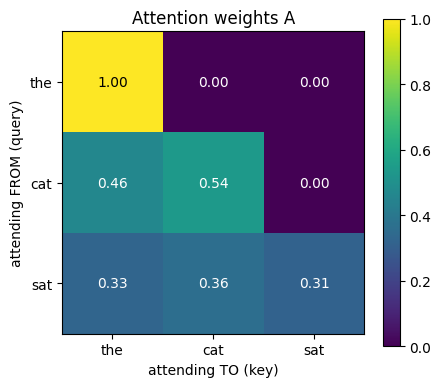

In [10]:
labels = [id_to_token[t] for t in ids]

fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(A, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(labels)
ax.set_yticks(range(n)); ax.set_yticklabels(labels)
ax.set_xlabel("attending TO (key)"); ax.set_ylabel("attending FROM (query)")
ax.set_title("Attention weights A")
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{A[i, j]:.2f}", ha="center", va="center",
                color="white" if A[i, j] < 0.6 else "black")
fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

---
## 8. Mix the values:  `Z = A · V`

The attention weights are used to take a **weighted average of the value vectors**:

$$Z = A V \qquad (n\times n)\cdot(n \times d_k) = (n \times d_k)$$

That is the whole trick. Attention never invents information — it only re-weights and copies
value vectors that already exist. It is a *soft* lookup: instead of picking one row, it blends them.

In [11]:
Z = A @ Vmat
show("Z = A @ V", Z, "(n x d_k)")

print("Check by hand — the last row of Z should equal")
print("  0.326*V[0] + 0.360*V[1] + 0.314*V[2]")
manual = A[2, 0]*Vmat[0] + A[2, 1]*Vmat[1] + A[2, 2]*Vmat[2]
print("  manual :", np.round(manual, 3))
print("  Z[2]   :", np.round(Z[2], 3))
print("  match  :", np.allclose(manual, Z[2]))

Z = A @ V   shape = (3, 4)   (n x d_k)
[[0.335 1.695 0.255 1.215]
 [0.971 1.174 0.535 1.191]
 [1.019 0.867 0.652 1.277]]

Check by hand — the last row of Z should equal
  0.326*V[0] + 0.360*V[1] + 0.314*V[2]
  manual : [1.019 0.867 0.652 1.277]
  Z[2]   : [1.019 0.867 0.652 1.277]
  match  : True


---
## 9. The LM head — from vectors back to words

We now have one `d`-dimensional vector per position. To turn the *last* one into a prediction we
project it back to vocabulary size:

$$\text{logits} = Z \cdot W_U \qquad (n \times d)\cdot(d \times V) = (n \times V)$$

Many real models use **weight tying**: they reuse the transposed embedding matrix,
$W_U = E^{\top}$. It saves `V·d` parameters and ties the two directions of the same vocabulary
space together. We do the same here.

A **logit is not a probability** — it is a raw, unbounded score. `softmax` turns the whole row into
`V` positive numbers that sum to 1.

In [12]:
W_U = E.T                 # weight tying: the unembedding is the transposed embedding
logits = Z @ W_U
show("logits", logits, "(n x V — one score per vocabulary word, per position)")

# At generation time only the LAST row matters: it scores the token that comes next.
last_logits = logits[-1]
probs = softmax(last_logits)

print(f"prompt: {prompt!r}\n")
print(f"{'token':>8} {'logit':>8} {'prob':>8}")
for j in np.argsort(-probs):
    bar = "#" * int(round(probs[j] * 60))
    print(f"{vocab[j]:>8} {last_logits[j]:8.3f} {probs[j]:8.3f}  {bar}")

print(f"\nprobabilities sum to {probs.sum():.6f}")
print(f"\n>>> the model predicts: {vocab[int(np.argmax(probs))]!r}")

logits   shape = (3, 6)   (n x V — one score per vocabulary word, per position)
[[0.    1.982 0.859 1.737 2.377 0.864]
 [0.    1.661 1.507 1.957 2.367 1.442]
 [0.    1.432 1.614 2.006 2.269 1.479]]

prompt: 'the cat sat'

   token    logit     prob
      on    2.269    0.305  ##################
     sat    2.006    0.234  ##############
     cat    1.614    0.158  ##########
     mat    1.479    0.138  ########
     the    1.432    0.132  ########
   <pad>    0.000    0.032  ##

probabilities sum to 1.000000

>>> the model predicts: 'on'


### ✅ Checkpoint

You just ran a complete (if tiny) language model: **`"the cat sat"` → `"on"`**, with probability
≈ 0.305.

Those numbers are exactly the ones on slides 19 and 20 of the deck. Everything from here on adds the
machinery that makes real models *deep* and *trainable* — but the core idea is already behind you.

---
## 10. Temperature and sampling

Picking the highest-probability token every time (**greedy** decoding) is reproducible but
repetitive. Instead we usually reshape the distribution with a **temperature** `T` and then sample:

$$p_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

* `T < 1` → sharper, more confident, more repetitive
* `T = 1` → the distribution exactly as trained
* `T > 1` → flatter, more surprising, more likely to go off the rails

None of this is learned. **Sampling is a decision you make at run time**, after the model has
finished computing.

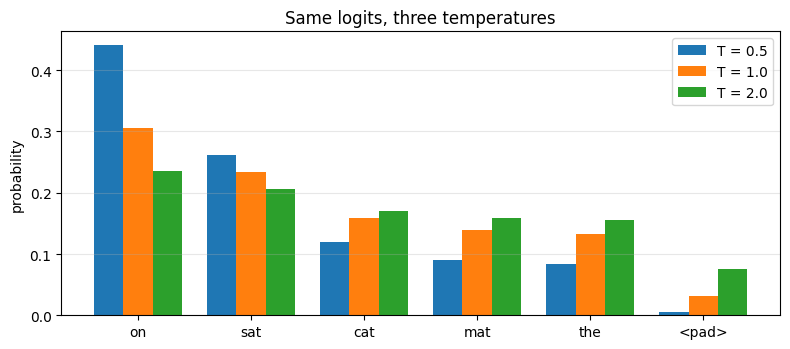

T=0.5:  on=0.441  sat=0.261  cat=0.119  mat=0.091
T=1.0:  on=0.305  sat=0.234  cat=0.158  mat=0.138
T=2.0:  on=0.235  sat=0.206  cat=0.170  mat=0.158


In [13]:
def apply_temperature(logits, T=1.0):
    return softmax(logits / max(T, 1e-8))


fig, ax = plt.subplots(figsize=(8, 3.6))
order = np.argsort(-probs)
width = 0.26
for k, T in enumerate([0.5, 1.0, 2.0]):
    p = apply_temperature(last_logits, T)
    ax.bar(np.arange(V) + (k - 1) * width, p[order], width, label=f"T = {T}")
ax.set_xticks(range(V)); ax.set_xticklabels([vocab[j] for j in order])
ax.set_ylabel("probability"); ax.set_title("Same logits, three temperatures")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

for T in (0.5, 1.0, 2.0):
    p = apply_temperature(last_logits, T)
    print(f"T={T}:  " + "  ".join(f"{vocab[j]}={p[j]:.3f}" for j in order[:4]))

Two more standard tricks, both applied to the probability vector **before** sampling:

* **top-k** — keep only the `k` highest-probability tokens, set the rest to zero, renormalise.
* **top-p (nucleus)** — keep the smallest set of tokens whose probabilities add up to `p`.

In [14]:
def top_k_filter(p, k):
    p = p.copy()
    if k < len(p):
        cutoff = np.sort(p)[-k]
        p[p < cutoff] = 0.0
    return p / p.sum()

def top_p_filter(p, top_p):
    order = np.argsort(-p)
    cumulative = np.cumsum(p[order])
    keep = order[:np.searchsorted(cumulative, top_p) + 1]
    out = np.zeros_like(p)
    out[keep] = p[keep]
    return out / out.sum()


print("original :", np.round(probs, 3))
print("top-k=3  :", np.round(top_k_filter(probs, 3), 3))
print("top-p=0.7:", np.round(top_p_filter(probs, 0.7), 3))

original : [0.032 0.132 0.158 0.234 0.305 0.138]
top-k=3  : [0.    0.    0.227 0.336 0.437 0.   ]
top-p=0.7: [0.    0.    0.189 0.28  0.365 0.166]


---
## 11. Generation — the autoregressive loop

Predicting one token is the whole model. To produce a sentence you simply **append the prediction to
the input and run everything again**. That loop is what "autoregressive" means.

Let's wrap sections 2–9 into a single function so we can call it repeatedly.

In [15]:
def mini_forward(ids):
    """Embedding + position + one attention head + tied LM head. Returns logits (n, V)."""
    n = len(ids)
    X = E[ids] + positional_encoding(n, d)
    Q, K, Vm = X @ W_Q, X @ W_K, X @ W_V
    S = Q @ K.T / np.sqrt(d_k)
    S[np.triu(np.ones((n, n)), k=1).astype(bool)] = -np.inf
    Z = softmax(S) @ Vm
    return Z @ W_U


def generate(prompt, max_new_tokens=4, T=1.0, greedy=True, seed=0):
    rng = np.random.default_rng(seed)
    ids = encode(prompt)
    for _ in range(max_new_tokens):
        logits = mini_forward(ids)[-1]        # only the LAST row matters
        p = apply_temperature(logits, T)
        nxt = int(np.argmax(p)) if greedy else int(rng.choice(len(p), p=p))
        ids = ids + [nxt]
        print(f"  {decode(ids[:-1]):<28} -> {id_to_token[nxt]!r}   (p = {p[nxt]:.3f})")
    return decode(ids)


print("GREEDY (always take the most likely token):")
out = generate("the cat sat", max_new_tokens=4, greedy=True)
print("\nresult:", repr(out))

print("\n\nSAMPLING at T = 1.0 (random, but reproducible via seed):")
out = generate("the cat sat", max_new_tokens=4, greedy=False, T=1.0, seed=3)
print("\nresult:", repr(out))

GREEDY (always take the most likely token):
  the cat sat                  -> 'on'   (p = 0.305)
  the cat sat on               -> 'on'   (p = 0.301)
  the cat sat on on            -> 'on'   (p = 0.298)
  the cat sat on on on         -> 'on'   (p = 0.303)

result: 'the cat sat on on on on'


SAMPLING at T = 1.0 (random, but reproducible via seed):
  the cat sat                  -> 'the'   (p = 0.132)
  the cat sat the              -> 'cat'   (p = 0.161)
  the cat sat the cat          -> 'on'   (p = 0.277)
  the cat sat the cat on       -> 'on'   (p = 0.285)

result: 'the cat sat the cat on on'


> ⚠️ The output is nonsense — and that is expected. We **hand-wrote** `E`, `W_Q`, `W_K`, `W_V`
> instead of training them. A real model finds these numbers by minimising prediction error over
> trillions of tokens. The *mechanism* is identical; only the values differ.
>
> Notice also that greedy decoding gets stuck in a loop. That is exactly why temperature, top-k and
> top-p exist.

---
# Part 2 — the rest of a real Transformer

Everything above was the *core*. A production model wraps that core in four more pieces:

1. **Multi-head attention** — run attention `h` times in parallel on narrower slices
2. **Residual connections** — add the input back, so gradients can flow
3. **LayerNorm** — keep the numbers at a sane scale
4. **A feed-forward network** — where most of the parameters actually live

Then it stacks the whole thing `N` times.

## 12. Multi-head attention

Instead of one attention operation of width `d`, run `h` of them on slices of width
`d_k = d / h`, then glue the results back together:

$$\text{head}_i = \text{Attention}(XW_Q^i,\; XW_K^i,\; XW_V^i)$$
$$\text{MHA}(X) = \text{Concat}(\text{head}_1 \dots \text{head}_h)\, W_O$$

**Why?** One head has to average every kind of relationship into a single pattern. Twelve heads can
specialise — one tracks the subject, one tracks the previous token, one tracks matching brackets.

**And it is free.** Because `h · d_k = d`, splitting into `h` heads costs exactly the same
number of multiplications as one head of width `d`.

In [16]:
def split_heads(M, h):
    """(n, d) -> (h, n, d_k)"""
    n, d_model = M.shape
    return M.reshape(n, h, d_model // h).transpose(1, 0, 2)

def merge_heads(M):
    """(h, n, d_k) -> (n, d)"""
    h, n, dk = M.shape
    return M.transpose(1, 0, 2).reshape(n, h * dk)


def causal_mask(n):
    return np.triu(np.ones((n, n)), k=1).astype(bool)


def multi_head_attention(X, Wq, Wk, Wv, Wo, h):
    n, d_model = X.shape
    d_head = d_model // h

    Q, K, Vm = X @ Wq, X @ Wk, X @ Wv            # each (n, d)
    Qh, Kh, Vh = split_heads(Q, h), split_heads(K, h), split_heads(Vm, h)

    scores = Qh @ Kh.transpose(0, 2, 1) / np.sqrt(d_head)   # (h, n, n)
    scores[:, causal_mask(n)] = -np.inf
    attn = softmax(scores, axis=-1)                          # (h, n, n)

    Zh = attn @ Vh                                           # (h, n, d_head)
    return merge_heads(Zh) @ Wo, attn


# Demo with a slightly bigger toy: d = 8, h = 2 heads of width 4
rng = np.random.default_rng(42)
d_demo, h_demo = 8, 2
X_demo = rng.normal(size=(n, d_demo)) * 0.5
Wq_d, Wk_d, Wv_d, Wo_d = (rng.normal(size=(d_demo, d_demo)) * 0.3 for _ in range(4))

out_mha, attn_per_head = multi_head_attention(X_demo, Wq_d, Wk_d, Wv_d, Wo_d, h_demo)

print(f"input  X : {X_demo.shape}")
print(f"h = {h_demo} heads, each of width d_k = {d_demo // h_demo}")
print(f"attention weights per head : {attn_per_head.shape}   (h, n, n)")
print(f"output   : {out_mha.shape}   <- back to (n, d), same as the input\n")
for i in range(h_demo):
    print(f"head {i} attention:\n{np.round(attn_per_head[i], 3)}\n")

input  X : (3, 8)
h = 2 heads, each of width d_k = 4
attention weights per head : (2, 3, 3)   (h, n, n)
output   : (3, 8)   <- back to (n, d), same as the input

head 0 attention:
[[1.    0.    0.   ]
 [0.529 0.471 0.   ]
 [0.328 0.331 0.341]]

head 1 attention:
[[1.    0.    0.   ]
 [0.473 0.527 0.   ]
 [0.351 0.336 0.313]]



## 13. Residual connections and LayerNorm

Two small ideas that make depth possible.

**Residual** — add the input back to the output of every sub-layer:

$$x \leftarrow x + \text{Sublayer}(x)$$

Each sub-layer then only has to learn a small *correction*, and gradients flow straight through the
`+` back to layer 1. Without this, 96-layer models simply do not converge.

**LayerNorm** — rescale each token's `d` features to mean 0 and variance 1, then apply two learned
vectors `γ` (scale) and `β` (shift):

$$\text{LN}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \varepsilon}} + \beta$$

Note that `μ` and `σ` are computed **across the features of one token**, not across the batch —
that is what distinguishes LayerNorm from BatchNorm.

before LayerNorm: [ 3.2 -1.4  8.7  0.5 -4.1  6.3  2.  -0.8]
   mean = 1.800   std = 3.927

after  LayerNorm: [ 0.357 -0.815  1.757 -0.331 -1.502  1.146  0.051 -0.662]
   mean = -0.000   std = 1.000


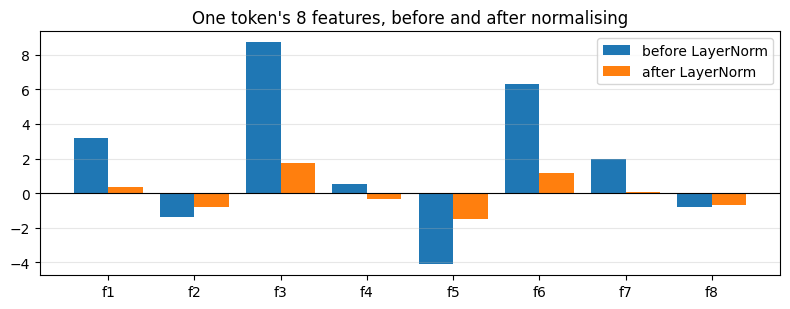

In [17]:
def layer_norm(X, gamma, beta, eps=1e-5):
    mu  = X.mean(axis=-1, keepdims=True)
    var = X.var(axis=-1, keepdims=True)
    return gamma * (X - mu) / np.sqrt(var + eps) + beta


noisy = np.array([[3.2, -1.4, 8.7, 0.5, -4.1, 6.3, 2.0, -0.8]])
gamma = np.ones(8)     # learned; initialised to 1
beta  = np.zeros(8)    # learned; initialised to 0

normed = layer_norm(noisy, gamma, beta)

print("before LayerNorm:", noisy[0])
print(f"   mean = {noisy.mean():.3f}   std = {noisy.std():.3f}\n")
print("after  LayerNorm:", np.round(normed[0], 3))
print(f"   mean = {normed.mean():.3f}   std = {normed.std():.3f}")

fig, ax = plt.subplots(figsize=(8, 3.2))
idx = np.arange(8)
ax.bar(idx - 0.2, noisy[0],   0.4, label="before LayerNorm")
ax.bar(idx + 0.2, normed[0],  0.4, label="after LayerNorm")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(idx); ax.set_xticklabels([f"f{i+1}" for i in idx])
ax.set_title("One token's 8 features, before and after normalising")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## 14. The feed-forward network — where most parameters live

$$\text{FFN}(x) = \text{GELU}(x W_1 + b_1)\, W_2 + b_2$$

It expands each token from `d` to `d_ff = 4d`, applies a non-linearity, then compresses back to `d`.

Two things to notice:

* It is applied to **each token's row independently** — the FFN never looks sideways at other
  tokens. Only attention does that.
* It holds roughly **two thirds of every block's parameters**: `2·d·d_ff = 8d²` versus `4d²` for
  all of attention.

X       : (3, 8)   (d     = 8)
hidden  : (3, 32)   (d_ff  = 32)   <- expanded 4x
output  : (3, 8)   (d     = 8)   <- compressed back


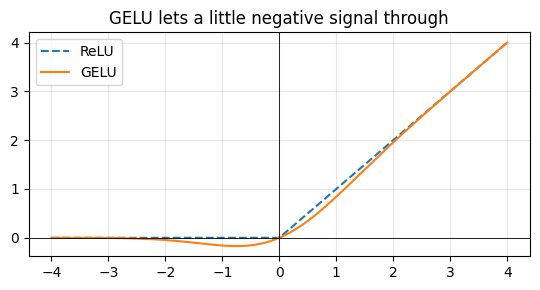

In [18]:
def gelu(x):
    """Gaussian Error Linear Unit — a smooth ReLU."""
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))


def feed_forward(X, W1, b1, W2, b2):
    return gelu(X @ W1 + b1) @ W2 + b2


d_ff_demo = 4 * d_demo
W1 = rng.normal(size=(d_demo, d_ff_demo)) * 0.2
b1 = np.zeros(d_ff_demo)
W2 = rng.normal(size=(d_ff_demo, d_demo)) * 0.2
b2 = np.zeros(d_demo)

hidden = gelu(X_demo @ W1 + b1)
out_ffn = feed_forward(X_demo, W1, b1, W2, b2)

print(f"X       : {X_demo.shape}   (d     = {d_demo})")
print(f"hidden  : {hidden.shape}   (d_ff  = {d_ff_demo})   <- expanded 4x")
print(f"output  : {out_ffn.shape}   (d     = {d_demo})   <- compressed back")

xs = np.linspace(-4, 4, 200)
plt.figure(figsize=(5.5, 3))
plt.plot(xs, np.maximum(xs, 0), "--", label="ReLU")
plt.plot(xs, gelu(xs), label="GELU")
plt.axhline(0, color="black", lw=0.6); plt.axvline(0, color="black", lw=0.6)
plt.title("GELU lets a little negative signal through"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 15. One complete Transformer block

Put the four pieces together. This is the "Pre-LN" arrangement used by GPT-2 onward
(normalise *first*, then add the residual):

```
X ──> LayerNorm ──> Multi-Head Attention ──> (+) ──> H
 └─────────────── residual ──────────────────┘

H ──> LayerNorm ──> Feed-Forward ──────────> (+) ──> X'
 └─────────────── residual ──────────────────┘
```

**The shape never changes.** `n × d` in, `n × d` out — which is exactly why blocks can be stacked
`N` times without any reshaping.

In [19]:
def transformer_block(X, p, h):
    # --- sub-layer 1: attention ---
    normed = layer_norm(X, p["ln1_g"], p["ln1_b"])
    attn_out, _ = multi_head_attention(normed, p["Wq"], p["Wk"], p["Wv"], p["Wo"], h)
    H = X + attn_out                      # residual

    # --- sub-layer 2: feed-forward ---
    normed2 = layer_norm(H, p["ln2_g"], p["ln2_b"])
    ffn_out = feed_forward(normed2, p["W1"], p["b1"], p["W2"], p["b2"])
    return H + ffn_out                    # residual


def random_block_params(d_model, rng, scale=0.2):
    d_ff = 4 * d_model
    return {
        "ln1_g": np.ones(d_model),  "ln1_b": np.zeros(d_model),
        "ln2_g": np.ones(d_model),  "ln2_b": np.zeros(d_model),
        "Wq": rng.normal(size=(d_model, d_model)) * scale,
        "Wk": rng.normal(size=(d_model, d_model)) * scale,
        "Wv": rng.normal(size=(d_model, d_model)) * scale,
        "Wo": rng.normal(size=(d_model, d_model)) * scale,
        "W1": rng.normal(size=(d_model, d_ff))    * scale,
        "b1": np.zeros(d_ff),
        "W2": rng.normal(size=(d_ff, d_model))    * scale,
        "b2": np.zeros(d_model),
    }


params = random_block_params(d_demo, rng)
X_out = transformer_block(X_demo, params, h=h_demo)

print(f"in  : {X_demo.shape}")
print(f"out : {X_out.shape}   <- identical shape, different numbers\n")
print("input  row 0:", np.round(X_demo[0], 3))
print("output row 0:", np.round(X_out[0],  3))

in  : (3, 8)
out : (3, 8)   <- identical shape, different numbers

input  row 0: [ 0.152 -0.52   0.375  0.47  -0.976 -0.651  0.064 -0.158]
output row 0: [ 0.181 -0.491  2.236  0.189 -0.723 -1.231  0.251 -0.245]


Now stack `N` of them — the full forward pass of a GPT.

In [20]:
def gpt_forward(ids, E_tab, blocks, ln_f, h):
    """Full decoder-only forward pass. Returns logits of shape (n, V)."""
    n = len(ids)
    d_model = E_tab.shape[1]

    X = E_tab[ids] + positional_encoding(n, d_model)     # steps 1-3
    for p in blocks:                                     # steps 4-9, N times
        X = transformer_block(X, p, h)
    X = layer_norm(X, ln_f["g"], ln_f["b"])              # final norm
    return X @ E_tab.T                                   # step 10, tied LM head


# A small but complete model: V=6, d=8, h=2, N=4
E_big  = rng.normal(size=(V, d_demo)) * 0.3
blocks = [random_block_params(d_demo, rng) for _ in range(4)]
ln_f   = {"g": np.ones(d_demo), "b": np.zeros(d_demo)}

logits_full = gpt_forward(ids, E_big, blocks, ln_f, h=h_demo)
p_full = softmax(logits_full[-1])

print(f"ids    : {ids}   ({decode(ids)!r})")
print(f"logits : {logits_full.shape}   (n x V)\n")
for j in np.argsort(-p_full):
    print(f"  {vocab[j]:>8}  p = {p_full[j]:.3f}")
print(f"\n>>> prediction: {vocab[int(np.argmax(p_full))]!r}  (random weights, so it means nothing yet)")

ids    : [1, 2, 3]   ('the cat sat')
logits : (3, 6)   (n x V)

       sat  p = 0.391
       the  p = 0.199
     <pad>  p = 0.185
       mat  p = 0.099
       cat  p = 0.073
        on  p = 0.053

>>> prediction: 'sat'  (random weights, so it means nothing yet)


---
## 16. Counting the parameters

Where do the numbers actually live? Per block:

| part | parameters |
|---|---|
| attention `W_Q, W_K, W_V, W_O` | `4d²` |
| feed-forward `W₁, W₂` (with `d_ff = 4d`) | `8d²` |
| **total per block** | **`12d²`** |

Plus the embeddings, `V·d`. So a good rule of thumb is

$$\text{params} \approx 12 \cdot N \cdot d^2 + V \cdot d$$

Let's check it against the real GPT-2 Small, which has **124,439,808** parameters.

In [21]:
def count_params(V, d, N, n_max=1024, d_ff=None, tie_weights=True):
    d_ff = d_ff or 4 * d
    parts = {}
    parts["token embedding E"]  = V * d
    parts["position embedding P"] = n_max * d

    per_layer_attn_W = 4 * d * d
    per_layer_attn_b = 4 * d
    per_layer_ffn_W  = 2 * d * d_ff
    per_layer_ffn_b  = d_ff + d
    per_layer_ln     = 2 * 2 * d          # two LayerNorms, gamma + beta each

    parts["attention weights"] = N * per_layer_attn_W
    parts["feed-forward weights"] = N * per_layer_ffn_W
    parts["LayerNorm + biases"] = N * (per_layer_attn_b + per_layer_ffn_b + per_layer_ln) + 2 * d
    if not tie_weights:
        parts["LM head W_U"] = d * V
    return parts


gpt2_small = count_params(V=50257, d=768, N=12)
total = sum(gpt2_small.values())

print("GPT-2 Small  (V=50257, d=768, h=12, N=12, d_ff=3072)\n")
for k, v in sorted(gpt2_small.items(), key=lambda kv: -kv[1]):
    print(f"  {k:<24} {v:>12,}   {100*v/total:5.1f}%")
print(f"  {'TOTAL':<24} {total:>12,}")
print(f"\n  published figure         {124_439_808:>12,}")
print(f"  match: {total == 124_439_808}")

approx = 12 * 12 * 768**2 + 50257 * 768
print(f"\nrule of thumb  12*N*d^2 + V*d = {approx:,}   (within {100*abs(approx-total)/total:.1f}%)")

GPT-2 Small  (V=50257, d=768, h=12, N=12, d_ff=3072)

  feed-forward weights       56,623,104    45.5%
  token embedding E          38,597,376    31.0%
  attention weights          28,311,552    22.8%
  position embedding P          786,432     0.6%
  LayerNorm + biases            121,344     0.1%
  TOTAL                     124,439,808

  published figure          124,439,808
  match: True

rule of thumb  12*N*d^2 + V*d = 123,532,032   (within 0.7%)


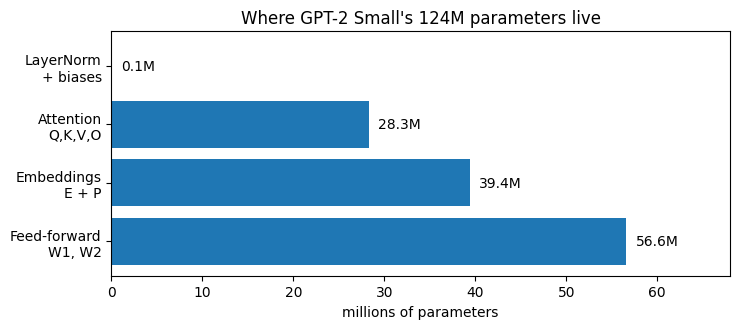

In [22]:
labels_p = ["Feed-forward\nW1, W2", "Embeddings\nE + P", "Attention\nQ,K,V,O", "LayerNorm\n+ biases"]
values_p = [gpt2_small["feed-forward weights"],
            gpt2_small["token embedding E"] + gpt2_small["position embedding P"],
            gpt2_small["attention weights"],
            gpt2_small["LayerNorm + biases"]]

plt.figure(figsize=(7.5, 3.4))
bars = plt.barh(labels_p, [v / 1e6 for v in values_p])
for b, v in zip(bars, values_p):
    plt.text(v/1e6 + 1, b.get_y() + b.get_height()/2, f"{v/1e6:.1f}M", va="center")
plt.xlabel("millions of parameters"); plt.xlim(0, 68)
plt.title("Where GPT-2 Small's 124M parameters live")
plt.tight_layout(); plt.show()

---
## 17. Why long context is expensive

Per layer, the cost splits in two:

* **projections + feed-forward** — `O(n · d²)`, grows *linearly* with sequence length
* **the attention matrix** — `O(n² · d)`, grows *quadratically*

Attention overtakes everything else once `n ≈ 6d`. Below that, people wrongly assume attention is
cheap; above it, attention is all you pay for.

      n    linear O(n d^2)   attention O(n^2 d)    ratio
    512             7.2 GF               0.8 GF     0.11x
   1024            14.5 GF               3.2 GF     0.22x
   2048            29.0 GF              12.9 GF     0.44x
   4096            58.0 GF              51.5 GF     0.89x
   8192           116.0 GF             206.2 GF     1.78x
  16384           231.9 GF             824.6 GF     3.56x

crossover at n = 6*d = 4608


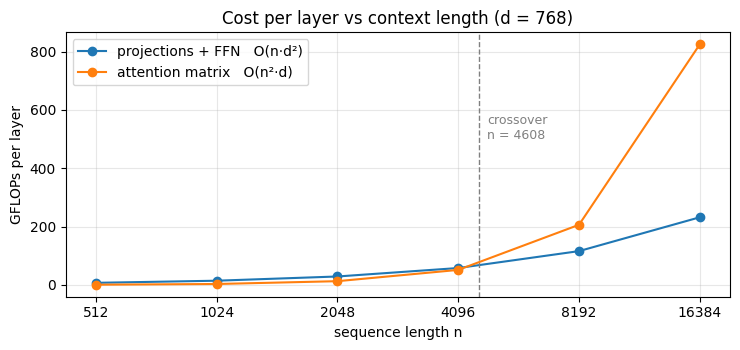

In [23]:
d_model = 768
ns = np.array([512, 1024, 2048, 4096, 8192, 16384])

linear_gflops = 24 * ns * d_model**2 / 1e9      # projections + FFN
attn_gflops   = 4 * ns**2 * d_model / 1e9       # scores + weighted sum

print(f"{'n':>7} {'linear O(n d^2)':>18} {'attention O(n^2 d)':>20} {'ratio':>8}")
for i, nn in enumerate(ns):
    print(f"{nn:>7} {linear_gflops[i]:>15.1f} GF {attn_gflops[i]:>17.1f} GF "
          f"{attn_gflops[i]/linear_gflops[i]:>8.2f}x")

crossover = 6 * d_model
print(f"\ncrossover at n = 6*d = {crossover}")

plt.figure(figsize=(7.5, 3.6))
plt.plot(ns, linear_gflops, marker="o", label="projections + FFN   O(n·d²)")
plt.plot(ns, attn_gflops,   marker="o", label="attention matrix   O(n²·d)")
plt.axvline(crossover, ls="--", color="grey", lw=1)
plt.text(crossover*1.05, 500, f"crossover\nn = {crossover}", fontsize=9, color="grey")
plt.xscale("log", base=2); plt.xticks(ns, [str(x) for x in ns])
plt.xlabel("sequence length n"); plt.ylabel("GFLOPs per layer")
plt.title(f"Cost per layer vs context length (d = {d_model})")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

This is also why the **KV cache** exists. During generation, `K` and `V` for earlier tokens never
change — so they are stored and reused, and each new token costs `O(n·d)` instead of `O(n²·d)`.
The price is memory: the cache grows linearly with context, and is often the real limit on how long
a conversation can get.

---
## 18. How training would work (concept only)

Everything above was **inference**: the weights are frozen and nothing is learned.

Training uses the very same forward pass, then adds a loss and a backward pass:

$$L = -\frac{1}{n}\sum_{t} \log p(x_{t+1} \mid x_{\leq t})$$

* One forward pass gives a prediction for **all `n` positions at once** — that is what the causal
  mask buys us.
* **Cross-entropy** compares each predicted distribution with the true next token.
* **Backpropagation** computes `∂L/∂W` for every matrix: `E`, `W_Q … W_O`, `W₁`, `W₂`, `γ`, `β`.
* An optimiser (AdamW) nudges each one. Repeat over trillions of tokens.

The cell below computes the loss for our toy model, just so you can see the number.

In [24]:
def cross_entropy_loss(logits, target_ids):
    """logits: (n, V) predictions for positions 0..n-1; target_ids: the true NEXT tokens."""
    p = softmax(logits, axis=-1)
    picked = p[np.arange(len(target_ids)), target_ids]
    return -np.mean(np.log(picked + 1e-12))


# Teach it the sentence "the cat sat on"
train_ids = encode("the cat sat on")
inputs  = train_ids[:-1]      # the cat sat
targets = train_ids[1:]       # cat sat on

lg = mini_forward(inputs)
loss = cross_entropy_loss(lg, targets)

print("inputs :", [id_to_token[i] for i in inputs])
print("targets:", [id_to_token[i] for i in targets])
print(f"\ncross-entropy loss = {loss:.4f}")
print(f"perplexity         = {np.exp(loss):.2f}   (a random model would score {V:.2f})")
print(f"\nA perfectly trained model would push this loss towards 0.")

inputs : ['the', 'cat', 'sat']
targets: ['cat', 'sat', 'on']

cross-entropy loss = 1.7478
perplexity         = 5.74   (a random model would score 6.00)

A perfectly trained model would push this loss towards 0.


---
## 19. Shape cheat sheet

Run this any time you lose track of what shape you are holding.

In [25]:
rows = [
    ("raw text",              '"the cat sat"'),
    ("token ids",             f"({n},)"),
    ("X_tok = E[ids]",        f"({n}, {d})      n x d"),
    ("X = X_tok + P",         f"({n}, {d})      n x d"),
    ("Q, K, V",               f"({n}, {d_k})      n x d_k   (x3)"),
    ("S = Q K^T / sqrt(d_k)", f"({n}, {n})      n x n"),
    ("A = softmax(S)",        f"({n}, {n})      n x n"),
    ("Z = A V",               f"({n}, {d_k})      n x d_k"),
    ("after W_O, +, LN",      f"({n}, {d})      n x d"),
    ("after FFN, +, LN",      f"({n}, {d})      n x d"),
    ("logits = X W_U",        f"({n}, {V})      n x V"),
    ("sampled token",         "1 integer"),
]
print(f"{'step':<26}{'shape'}")
print("-" * 58)
for a, b in rows:
    print(f"{a:<26}{b}")
print("-" * 58)
print("Between the embedding and the LM head, the hidden state stays n x d")
print("for the entire depth of the network. That invariant is why it scales.")

step                      shape
----------------------------------------------------------
raw text                  "the cat sat"
token ids                 (3,)
X_tok = E[ids]            (3, 4)      n x d
X = X_tok + P             (3, 4)      n x d
Q, K, V                   (3, 4)      n x d_k   (x3)
S = Q K^T / sqrt(d_k)     (3, 3)      n x n
A = softmax(S)            (3, 3)      n x n
Z = A V                   (3, 4)      n x d_k
after W_O, +, LN          (3, 4)      n x d
after FFN, +, LN          (3, 4)      n x d
logits = X W_U            (3, 6)      n x V
sampled token             1 integer
----------------------------------------------------------
Between the embedding and the LM head, the hidden state stays n x d
for the entire depth of the network. That invariant is why it scales.


---
## 20. Exercises

Work through these to check you really own the material.

**1. Break the mask.** Comment out the line that sets the upper triangle to `-inf` in
`mini_forward`, then re-run generation. What changes in `A`, and why would this make training
useless?

**2. Break the scaling.** Remove the `/ np.sqrt(d_k)` from the score computation and multiply `X`
by 10 first. Print `A`. What has happened to the attention weights, and what would that do to the
gradients?

**3. Order matters.** Run `mini_forward(encode("sat cat the"))` and compare with
`mini_forward(encode("the cat sat"))`. Now delete the `+ positional_encoding(...)` term and compare
again. What do you observe?

**4. Widen the model.** Change `d` from 4 to 16 (you will need to regenerate `E`, `W_Q`, `W_K`,
`W_V` at the new size — use `rng.normal(size=(...)) * 0.3`). Does the pipeline still run without any
other change? Why?

**5. Count a bigger model.** Use `count_params` to work out the size of a model with `d = 1024`,
`N = 24`, `V = 50257`. Which published model does that match?

**6. Head specialisation.** In `multi_head_attention`, print `attn_per_head[0]` and
`attn_per_head[1]`. Are the two heads attending to the same tokens? Now set both `Wq_d` and `Wk_d`
to the identity matrix — what happens to the attention pattern, and why?

**7. Temperature sweep.** Plot the probability of the top token as `T` goes from 0.1 to 5.0. At what
temperature does the distribution become effectively uniform?

**8. Stretch.** Implement `RMSNorm` — the same as LayerNorm but with no mean subtraction and no `β`:
$\text{RMSNorm}(x) = \gamma \odot x / \sqrt{\text{mean}(x^2) + \varepsilon}$. Swap it into
`transformer_block` and confirm the shapes still line up. This is what Llama uses.

---
## 21. Summary

1. **A language model is a next-token probability function.** Everything impressive is downstream of
   that one objective.
2. **Almost all of it is matrix multiplication.** Nine matrix families: `E`, `P`, `W_Q`, `W_K`,
   `W_V`, `W_O`, `W₁`, `W₂`, `W_U` — plus the vectors `γ` and `β`.
3. **Attention is a soft lookup, not magic.** Query·Key gives relevance, softmax turns relevance into
   weights, the weights average the values.
4. **The hidden state never changes shape.** `n × d` in, `n × d` out, `N` times over.
5. **Sampling happens after the model is done.** Temperature, top-k and top-p are choices you
   control, not properties the model learned.